# Computing Bottleneck Analysis

## Introduction

Sometimes I enjoy gaming on my PC, but I built it around 8 years ago, and on a budget. Therefore, it can sometimes struggle with performance. I was interested in gathering some data on my hardware utilisation and analysing the collected data to identify any obvious bottlenecks. With the insights gained from this data, the goal is to identify key issues or components that are consistently throttling game performance, which can then inform future purchases or upgrades.

Hardware data was collected with [HWiNFO](https://www.hwinfo.com/).

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt

from config import RAW_DATA_FILE_PATH, COLS

In [2]:
files = [
    os.path.join(RAW_DATA_FILE_PATH, f) for f in os.listdir(RAW_DATA_FILE_PATH)
]

dfs: list[pd.DataFrame] = []
for f in files:
    df = pd.read_csv(
        f, encoding="latin-1", usecols=COLS, skipfooter=2, engine="python"
    )  # HWIN adds info on final line we want to skip
    df["Series"] = os.path.basename(f)
    dfs.append(df)

panel = pd.concat(dfs, ignore_index=True)
panel

,Date,Time,Physical Memory Load [%],Max CPU/Thread Usage [%],Total CPU Usage [%],GPU Utilization [%],Average Effective Clock [MHz],Total CPU Utility [%],CPU (Tctl/Tdie) [°C],CPU Package Power [W],...,GPU D3D Usage [%],Framerate Presented (avg) [FPS],Framerate Presented (1% low) [FPS],Framerate Presented (0.1% low) [FPS],Frame Time Presented (avg) [ms],GPU Busy (avg) [ms],GPU Wait (avg) [ms],CPU Busy (avg) [ms],CPU Wait (avg) [ms],Series
0,13.2.2026,20:44:47.093,71.7,82.9,72.1,0.0,2880.1,68.9,45.2,15.070,...,1.3,15.8,1.9,1.9,63.25,0.12,37.07,63.10,0.15,eu4_2026_02_13.CSV
1,13.2.2026,20:44:49.097,72.0,71.9,63.3,0.0,2533.1,60.5,45.6,13.901,...,0.3,4.0,1.2,1.2,250.26,0.19,220.78,250.13,0.12,eu4_2026_02_13.CSV
2,13.2.2026,20:44:51.099,72.1,100.0,99.0,0.0,3787.4,92.1,47.1,15.859,...,0.1,3.0,1.2,1.2,328.30,0.10,0.00,328.17,0.14,eu4_2026_02_13.CSV
3,13.2.2026,20:44:53.094,72.0,100.0,99.4,0.0,3792.5,92.2,47.5,15.850,...,0.1,2.3,1.2,1.2,442.06,0.10,0.00,441.95,0.12,eu4_2026_02_13.CSV
4,13.2.2026,20:44:57.093,71.9,99.2,98.6,0.0,3774.8,91.6,47.8,16.010,...,3.2,23.7,8.5,8.5,42.26,0.10,0.00,42.14,0.12,eu4_2026_02_13.CSV
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39815,8.6.2026,0:17:45.297,34.3,4.7,2.9,0.0,179.9,4.0,50.9,5.869,...,0.1,1.1,0.5,0.5,942.51,0.16,942.32,942.39,0.12,eldenring_2026_06_07.CSV
39816,8.6.2026,0:17:47.292,34.0,14.1,11.3,0.0,493.3,13.0,48.6,7.213,...,0.0,1.1,0.5,0.5,950.88,0.16,950.71,950.77,0.12,eldenring_2026_06_07.CSV
39817,8.6.2026,0:17:49.292,33.8,3.1,1.7,0.0,173.0,3.9,45.9,5.831,...,0.1,1.1,0.5,0.5,942.58,0.22,942.38,942.46,0.13,eldenring_2026_06_07.CSV
39818,8.6.2026,0:17:51.291,33.7,3.1,2.3,0.0,168.6,3.6,45.1,5.661,...,0.1,1.1,0.5,0.5,942.41,0.29,942.10,942.29,0.12,eldenring_2026_06_07.CSV


In [3]:
list(panel)

['Date',
 'Time',
 'Physical Memory Load [%]',
 'Max CPU/Thread Usage [%]',
 'Total CPU Usage [%]',
 'GPU Utilization [%]',
 'Average Effective Clock [MHz]',
 'Total CPU Utility [%]',
 'CPU (Tctl/Tdie) [°C]',
 'CPU Package Power [W]',
 'CPU TDC Limit [%]',
 'GPU Thermal Diode [°C]',
 'GPU Core Power [W]',
 'GPU D3D Usage [%]',
 'Framerate Presented (avg) [FPS]',
 'Framerate Presented (1% low) [FPS]',
 'Framerate Presented (0.1% low) [FPS]',
 'Frame Time Presented (avg) [ms]',
 'GPU Busy (avg) [ms]',
 'GPU Wait (avg) [ms]',
 'CPU Busy (avg) [ms]',
 'CPU Wait (avg) [ms]',
 'Series']

## Variables
Below is a list of all the variables in the dataset and a brief explanation of them.
- Physical Memory Load [%] — RAM pressure
- Max CPU/Thread Usage [%] — load on most used thread
- Total CPU Usage [%] — overall CPU load
- Total CPU Utility [%] — how efficiently the CPU is being used
- GPU Utilization [%] — GPU load
- GPU D3D Usage [%] — measures GPU time spent on actual game rendering, not background other tasks
- Average Effective Clock [MHz] — if this drops under load, throttling is occuring
- CPU (Tctl/Tdie) [°C] — whether CPU is self-throttling due to high temps
- GPU Thermal Diode [°C] — whether CPU is self-throttling due to high temps
- CPU Package Power [W] — whether CPU is power-limited
- GPU Core Power [W] — whether GPU is power-limited
- CPU TDC Limit [%] — current limit from motherboard. Performance is throttled by motherboard power delivery
- Framerate Presented (avg) [FPS] + (1% low) [FPS] + (0.1% low) [FPS] — the actual outcome, dependent variable
- Frame Time Presented (avg) [ms] - inverse of framerate. correlated, but can add clarity.
- CPU Busy (avg) [ms] vs GPU Busy (avg) [ms] — most direct bottleneck indicator: whichever is higher is the bottleneck
- CPU Wait (avg) [ms] vs GPU Wait (avg) [ms] — complements above, showing direction of bottleneck

Create proper datetime column, and drop parent cols. This will help us with graphing.

In [4]:
panel["Datetime"] = pd.to_datetime(
    panel["Date"] + " " + panel["Time"], dayfirst=True
)
panel = panel.drop(["Date", "Time"], axis=1)

Let's also check for any null or NA data in the dataframe.

In [5]:
panel.loc[panel.isna().any(axis=1)]

,Physical Memory Load [%],Max CPU/Thread Usage [%],Total CPU Usage [%],GPU Utilization [%],Average Effective Clock [MHz],Total CPU Utility [%],CPU (Tctl/Tdie) [°C],CPU Package Power [W],CPU TDC Limit [%],GPU Thermal Diode [°C],...,Framerate Presented (avg) [FPS],Framerate Presented (1% low) [FPS],Framerate Presented (0.1% low) [FPS],Frame Time Presented (avg) [ms],GPU Busy (avg) [ms],GPU Wait (avg) [ms],CPU Busy (avg) [ms],CPU Wait (avg) [ms],Series,Datetime


Let's graph CPU vs GPU Busy to get a quick overview of the data. We use a rolling average because without it, the data is a wall of noise. Metrics can fluctuate heavily from frame-to-frame, so using a rolling average helps us reveal the underlying trend.

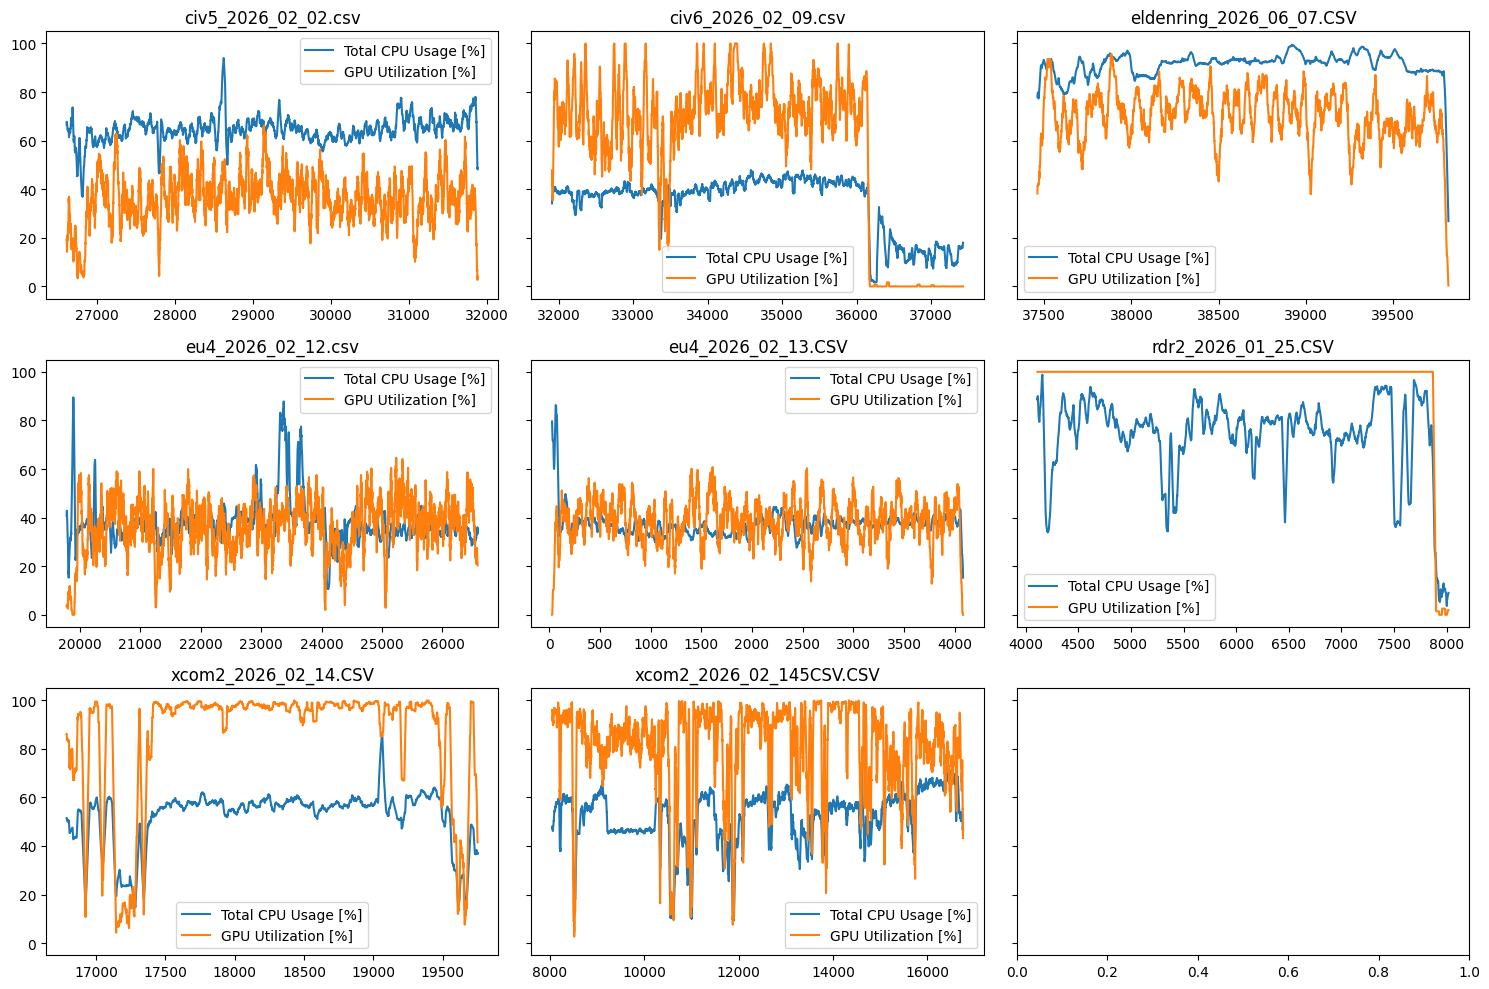

In [6]:
fig, ax = plt.subplots(3, 3, sharey=True, figsize=(15, 10))
for i, (name, df) in enumerate(panel.groupby("Series")):
    row, col = i // 3, i % 3  # map flat index to 2D grid position
    df[["Total CPU Usage [%]", "GPU Utilization [%]"]].rolling(
        window=30
    ).mean().plot(ax=ax[row, col])
    ax[row, col].set_title(name)
fig.tight_layout()
plt.show()

Immediately obvious, is that some further data cleaning is required. Data was recorded by pressing a 'logging' button, and this logging was sometimes ended significantly after the game was stopped. This results in the sudden (and in the civ6 series, quite prolonged) drop in utilisation.

Let's create a function to trim the beginnning and end of each series, where D3D (game frame rendering) is significantly low. This will help us focus only on relevant data.

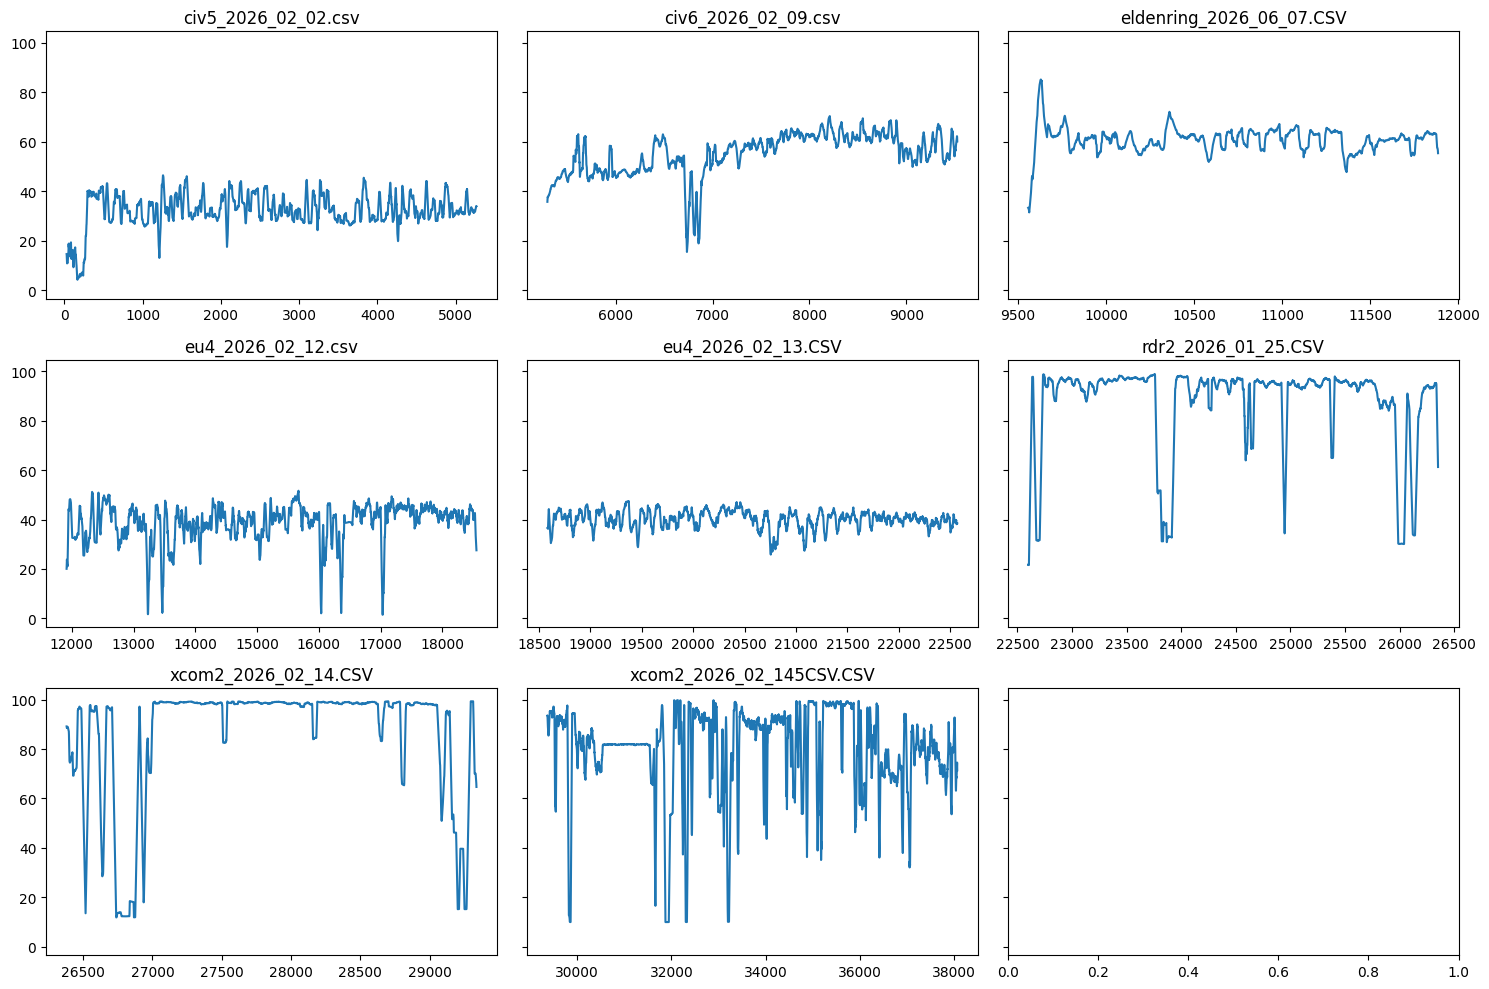

In [7]:
def trim_data(df: pd.DataFrame, threshold: int = 15) -> pd.DataFrame:
    last_active = df["GPU D3D Usage [%]"].gt(threshold).where(lambda x: x).last_valid_index()
    first_active = df["GPU D3D Usage [%]"].gt(threshold).where(lambda x: x).first_valid_index()
    return df.loc[first_active:last_active]

panel = pd.concat([trim_data(df) for _, df in panel.groupby("Series")], ignore_index=True)
    
fig, ax = plt.subplots(3, 3, sharey=True, figsize=(15, 10))
for i, (name, df) in enumerate(panel.groupby("Series")):
    row, col = i // 3, i % 3  # map flat index to 2D grid position
    df["GPU D3D Usage [%]"].rolling(window=30).mean().plot(ax=ax[row, col])
    ax[row, col].set_title(name)
    
fig.tight_layout()
plt.show()